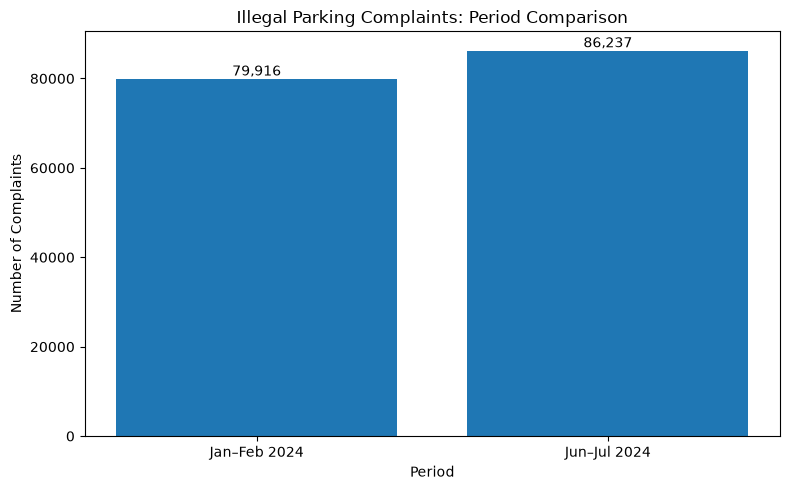

In [1]:
import matplotlib.pyplot as plt

periods = ["Jan–Feb 2024", "Jun–Jul 2024"]
counts = [79916, 86237]

plt.figure(figsize=(8, 5))
bars = plt.bar(periods, counts)

plt.title("Illegal Parking Complaints: Period Comparison")
plt.xlabel("Period")
plt.ylabel("Number of Complaints")

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [2]:
difference = counts[1] - counts[0]
percent_increase = difference / counts[0] * 100

print(f"January–February: {counts[0]:,}")
print(f"June–July: {counts[1]:,}")
print(f"Increase: {difference:,} complaints")
print(f"Percentage increase: {percent_increase:.2f}%")

January–February: 79,916
June–July: 86,237
Increase: 6,321 complaints
Percentage increase: 7.91%


## Task 3: Complaint comparison using CLI output
This cell reads `jan_feb.csv` and `jun_jul.csv`, the outputs generated by `complaint_borough.py`. It does not hardcode the complaint counts.

## Task 3: Complaint comparison using CLI output
This cell reads `jan_feb.csv` and `jun_jul.csv`, the outputs generated by `complaint_borough.py`. It does not hardcode the complaint counts.

In [ ]:
# Task 3: Compare the CLI results for the two periods.
# These CSV files are generated by complaint_borough.py, not hardcoded counts.
import csv
from collections import Counter
import matplotlib.pyplot as plt
from pathlib import Path

def read_complaint_counts(filename):
    with open(filename, newline="", encoding="utf-8-sig") as f:
        reader = csv.DictReader(f)
        headers = reader.fieldnames or []
        norm = lambda s: "".join(c.lower() for c in (s or "") if c.isalnum())
        complaint_col = next((h for h in headers if norm(h) in
                              {"complainttype", "complaint", "type"}), None)
        count_col = next((h for h in headers if norm(h) in
                          {"count", "complaintcount", "total"}), None)
        if not complaint_col or not count_col:
            raise ValueError(
                f"Could not identify complaint/count columns in {filename}. "
                f"Headers found: {headers}"
            )
        totals = Counter()
        for row in reader:
            complaint = (row.get(complaint_col) or "").strip()
            if complaint:
                totals[complaint] += int(float(row[count_col]))
        return totals

jan_feb = read_complaint_counts("jan_feb.csv")
jun_jul = read_complaint_counts("jun_jul.csv")

# Compare the most abundant complaint type from the full 2024 analysis.
target = "Illegal Parking"
periods = ["January–February 2024", "June–July 2024"]
counts = [jan_feb.get(target, 0), jun_jul.get(target, 0)]

print("Complaint type:", target)
print(f"{periods[0]}: {counts[0]:,}")
print(f"{periods[1]}: {counts[1]:,}")
if counts[0]:
    print(f"Change: {counts[1] - counts[0]:+,} "
          f"({(counts[1] - counts[0]) / counts[0] * 100:+.2f}%)")

plt.figure(figsize=(8, 5))
bars = plt.bar(periods, counts)
plt.title(f"{target} Complaints: Jan–Feb vs Jun–Jul 2024")
plt.ylabel("Number of complaints")
plt.xlabel("Period")
plt.bar_label(bars, labels=[f"{n:,}" for n in counts], padding=3)
plt.tight_layout()
plt.show()
